In [ ]:
import pandas as pd
import numpy as np
from typing import Tuple

from sklearn.metrics import mean_squared_error

import pymc as pm
import xarray as xr
import arviz as az
import arviz_plots as azp

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.text as mtext

RANDOM_SEED = 457775 # https://www.reddit.com/r/baseball/comments/b5vfik/whos_the_most_random_mlb_player_you_can_think_of/
np.random.seed(RANDOM_SEED)

# for reproducibility
print("pandas: "+pd.__version__)
print("numpy: "+np.__version__)
print("pymc: "+pm.__version__)
import pytensor
print("pytensor: "+pytensor.__version__)
print("arviz: "+az.__version__)
print("arviz_plots: "+azp.__version__)

pandas: 3.0.5
numpy: 2.4.3
pymc: 6.2.0
pytensor: 3.2.4
arviz: 1.3.0
arviz_plots: 1.3.0


In [2]:
# These are some generic helper functions to help sample for the model
def sample(model: pm.Model, draws: int = 2000, tune: int = 2000, chains: int = 4, target_accept: float = 0.99, random_seed: int = RANDOM_SEED, path:str = 'temp.nc', **kwargs)-> xr.DataTree:
    """
    Fit model using MCMC.

    Parameters
    ----------
    model: pm.Model
        PyMC model object.
    draws : int
        Number of draws to keep from the sampling process.
    tune : int
        Number of tuning steps to take before sampling.
    chains : int
        Number of chains to sample.
    target_accept : float
        Target acceptance probability for step size adaptation.
    random_seed : int
        Seed for randomness.
    """
    with model:
        trace = pm.sample(
            draws=draws,
            tune=tune,
            chains=chains,
            target_accept=target_accept,
            random_seed=random_seed,
            idata_kwargs={"log_likelihood": False}
        )
    try:
        xr.DataTree.to_netcdf(trace, path)
    except Exception as e:
        print(f"Error saving trace to {path}: {e}")
    return trace

def compute_log_likelihood(model: pm.Model, trace: xr.DataTree) -> xr.DataTree:
    """Wrapper to compute elemwise log_likelihood of model given InferenceData with posterior group
    Args:
        model (pm.Model): A PyMC model object
        trace (xr.DataTree): Results from sampling
    """
    with model:
        pm.compute_log_likelihood(trace)
    return None

def sample_posterior_pred(model: pm.Model, trace: xr.DataTree) -> xr.DataTree:
    """Generates samples from the posterior predictive distribution for model checks

    Args:
        model (pm.Model): A PyMC model object
        trace (xr.DataTree): Results from sampling

    Returns:
        xr.DataTree: An ArviZ InferenceData object containing the posterior predictive samples.
    """
    with model:
        spp = pm.sample_posterior_predictive(
            trace,
            extend_inferencedata=True,
            random_seed=RANDOM_SEED,
        )
    return spp

In [3]:
# first use handy index function
def define_index(data: pd.DataFrame, label: str) -> Tuple[np.array, dict]:
    """Defines an index variable starting at 0.
    Args:
        data (pd.DataFrame): dataframe with values to index
        label (str): column name user wishes to index in string format

    Returns:
        Union[
            np.array: indexed values
            dict: dictionary mapping the input values and their indexed values
            ]
    """
    unq_ids = data[label].astype(str).unique()
    lookup = {v: i for i, v in enumerate(unq_ids)}
    index_vals = data[label].astype(str).map(lookup).values.astype("int32")
    return index_vals, lookup

def map_index(data: pd.DataFrame, label: str, lookup_dict: dict) -> np.array:
    """Applies an index to new values
    Args:
        data (pd.DataFrame): dataframe with values to index
        label (str): column name user wishes to index in string format
        lookup_dict (dict): dictionary that contains the mappings from inputs to index

    Returns:
        np.array: indexed values
    """
    s = data[label].astype(str)
    vals = s.map(lookup_dict).values
    return vals

In [4]:
# import data
df = pd.read_csv('data/bat_speed_model_data_monthly.csv')
df['bam_id'] = pd.to_numeric(df['bam_id'], errors='coerce')
df.head()

,bam_id,year,month_name,time_index,player_full_id,full,first,last,bats,birth_date,...,bips,ev90,latent_ev90_mean,latent_ev90_std,swing_total,bat_speed,imputed_bat_speed,model_bat_speed,is_imputed,is_complete
0,120074,2016,Mar/Apr,0,David Ortiz (120074),David Ortiz,David,Ortiz,L,1975-11-18,...,62.0,107.51,106.923259,0.669996,168.0,NaN,73.490941,73.490941,1,0
1,120074,2016,May,1,David Ortiz (120074),David Ortiz,David,Ortiz,L,1975-11-18,...,78.0,108.94,106.961690,0.641453,193.0,NaN,73.524456,73.524456,1,0
2,120074,2016,Jun,2,David Ortiz (120074),David Ortiz,David,Ortiz,L,1975-11-18,...,73.0,105.84,106.920999,0.627866,176.0,NaN,73.491806,73.491806,1,0
3,120074,2016,Jul,3,David Ortiz (120074),David Ortiz,David,Ortiz,L,1975-11-18,...,76.0,106.45,106.918319,0.637789,181.0,NaN,73.488981,73.488981,1,0
4,120074,2016,Aug,4,David Ortiz (120074),David Ortiz,David,Ortiz,L,1975-11-18,...,79.0,107.94,106.938944,0.660242,180.0,NaN,73.506715,73.506715,1,0


In [5]:
# standardize age
age_mean = np.mean(df['age'])
age_std = np.std(df['age'])
df['age_z'] = (df['age'] - age_mean)/age_std

# define age and age squared for the model
age_values = df['age_z'].values
age_sq_values = age_values**2

n_obs = len(df)
df["player_idx"], player_lookup = define_index(df, "player_full_id")
player_idx_vals = df['player_idx'].values.astype("int32")
player_name_list = list(player_lookup.keys())
is_imputed_data_vals = df['is_imputed'].values.astype("int32")

bat_speed_target = df['model_bat_speed'].values
swings_sqrt_values = np.sqrt(df['swing_total'].values)

# define emprical prior for bat speed
prior_mean = np.mean(bat_speed_target)
prior_std = np.std(bat_speed_target)
print(prior_mean)
print(prior_std)


70.01872920073318
2.6785917750237846


<Axes: >

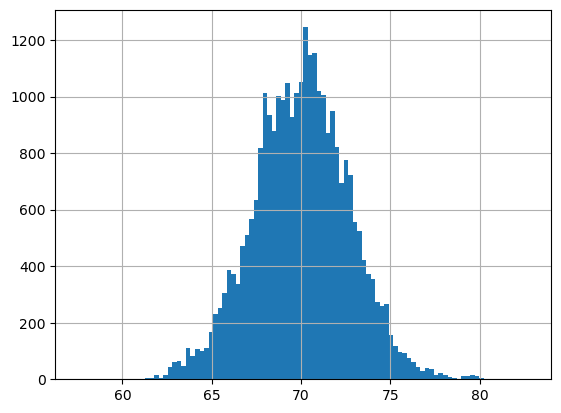

In [6]:
df['model_bat_speed'].hist(bins=100)

In [7]:
print(prior_mean+prior_std*1.25*3)
print(prior_mean-prior_std*1.25*3)

assert(np.isnan(swings_sqrt_values).sum() == 0)

80.06344835707237
59.974010044393985


In [8]:
coords = {
    "observation_id": np.arange(n_obs),
    "player": player_name_list,
}   

# pymc model
with pm.Model(coords=coords) as model_quad:
    # data
    player_idx = pm.Data("player_idx", player_idx_vals, dims=("observation_id",))
    age_data = pm.Data('age_data', age_values, dims=("observation_id",))
    age_sq_data = pm.Data('age_sq_data', age_sq_values, dims=("observation_id",))
    swings_sqrt = pm.Data('swings_sqrt', swings_sqrt_values, dims=("observation_id",))
    is_imputed_data = pm.Data('is_imputed_data', is_imputed_data_vals, dims=("observation_id",))
    target_data = pm.Data("target_data", bat_speed_target, dims=("observation_id",))
    
    # global intercept
    mu_pop = pm.Normal("mu_pop", mu=prior_mean, sigma=prior_std)

    # player random
    sigma_player = pm.HalfNormal("sigma_player", 1.0)
    mu_player = pm.Normal("mu_player", mu=mu_pop, sigma=sigma_player, dims=("player",))
    
    # age
    a = pm.Normal("a", mu=0, sigma=1)
    b = pm.Normal("b", mu=0, sigma=1)
    f = pm.Deterministic('f', a*age_sq_data + b*age_data)

    # expected value
    theta = mu_player[player_idx] + f
    sigma_imputed = pm.HalfNormal("sigma_imputed", sigma=1.0)
    sigma_observed = pm.HalfNormal("sigma_observed", sigma=1.0)
    sigma = pm.math.switch(is_imputed_data, sigma_imputed, sigma_observed)
    target = pm.Normal("target", mu=theta, sigma=sigma/swings_sqrt, observed=target_data, dims=("observation_id",))

In [9]:
trace_quad = sample(model_quad, draws = 2000, tune = 4000, target_accept = 0.99,  path='quad_model.nc')

NUTS[nutpie]: [mu_pop, sigma_player, mu_player, a, b, sigma_imputed, sigma_observed]


Output()

In [10]:
az.summary(trace_quad, var_names=['mu_pop', 'sigma_player', 'a', 'b', 'sigma_imputed', 'sigma_observed'], ci_prob=0.95, round_to=2)

,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_pop,69.65,0.06,69.53,69.78,12693.00,6451.04,1.0,0.0,0.0
sigma_player,2.53,0.05,2.44,2.62,12108.85,6644.97,1.0,0.0,0.0
a,-0.13,0.00,-0.14,-0.12,1980.80,3031.04,1.0,0.0,0.0
b,0.03,0.01,0.02,0.04,1976.60,2937.83,1.0,0.0,0.0
sigma_imputed,4.89,0.03,4.84,4.94,10853.02,6133.70,1.0,0.0,0.0
sigma_observed,14.22,0.11,14.01,14.44,10935.00,6673.95,1.0,0.0,0.0


In [11]:
az.summary(trace_quad, var_names=['mu_player'], ci_prob=0.95, round_to=2)

,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_player[David Ortiz (120074)],74.77,0.16,74.47,75.09,8387.67,5767.00,1.0,0.00,0.00
mu_player[Alex Rodriguez (121347)],72.98,0.23,72.53,73.44,11004.80,5653.85,1.0,0.00,0.00
mu_player[Adrian Beltré (134181)],70.29,0.10,70.10,70.47,7922.95,5643.16,1.0,0.00,0.00
mu_player[Carlos Beltrán (136860)],71.32,0.12,71.09,71.55,7291.78,5467.23,1.0,0.00,0.00
mu_player[Jayson Werth (150029)],72.26,0.13,72.02,72.51,11364.15,5808.79,1.0,0.00,0.00
...,...,...,...,...,...,...,...,...,...
mu_player[Brett Callahan (814430)],71.05,1.97,67.22,74.89,14024.16,5797.75,1.0,0.02,0.01
mu_player[Ryan Waldschmidt (814439)],71.58,0.72,70.16,72.99,14033.29,5382.35,1.0,0.01,0.00
mu_player[Sean Keys (815873)],73.12,1.34,70.54,75.70,15396.03,6312.79,1.0,0.01,0.01
mu_player[Sung-Mun Song (823550)],71.13,0.93,69.30,72.96,15120.35,5719.43,1.0,0.01,0.01


In [12]:
def plot_aging_curve(trace, age_z, model_name="Model"):
    f_draws = trace.posterior["f"].values
    curves = f_draws.reshape(-1, f_draws.shape[-1])

    sort_idx = np.argsort(age_z)
    age_sorted = age_z[sort_idx]
    curves_sorted = curves[:, sort_idx]

    _, ax = plt.subplots(figsize=(8, 6))
    rng = np.random.default_rng(RANDOM_SEED)
    subset_indices = rng.choice(curves_sorted.shape[0], size=500, replace=False)
    for idx in subset_indices:
        ax.plot(age_sorted, curves_sorted[idx, :], color="darkred", alpha=0.05)

    ax.set_title(f"{model_name} Aging Curve")
    ax.set_xlabel("Age (Z-Score)")
    ax.set_ylabel("Bat Speed Change (mph)")
    ax.set_ylim(-3, 1)
    ax.grid(True)
    plt.show()
    return curves_sorted

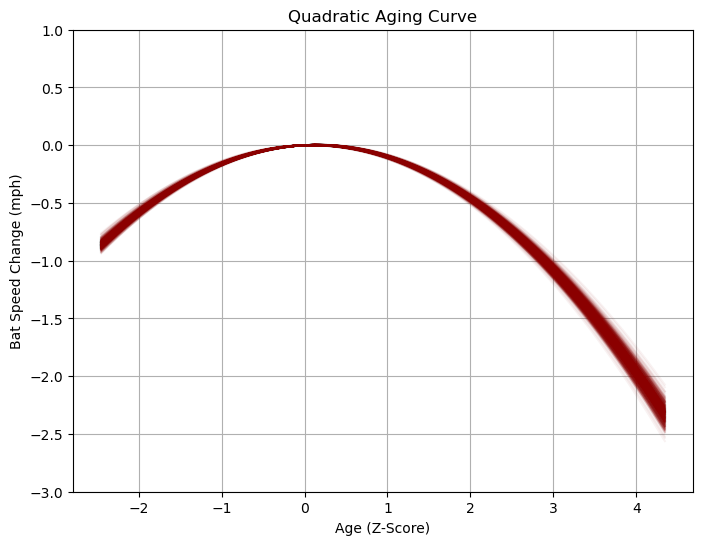

In [13]:
quad_aging_curve = plot_aging_curve(trace_quad, age_values, model_name="Quadratic")

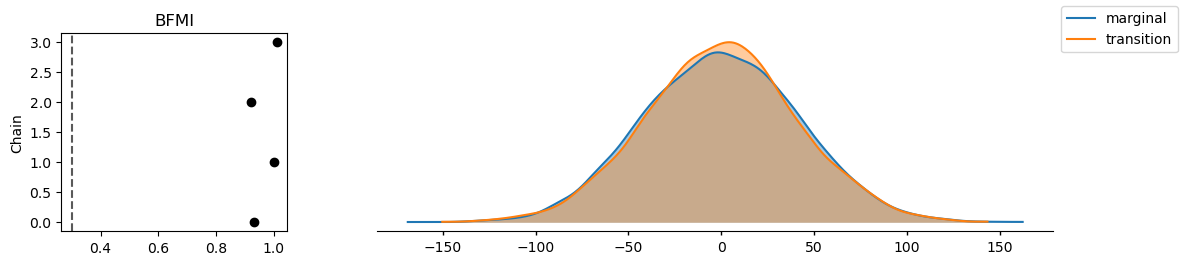

In [14]:
az.plot_energy(trace_quad)

In [15]:
spp = sample_posterior_pred(model_quad, trace_quad)

Sampling: [target]


Output()

Text(0.5, 0, 'Bat Speed (mph)')

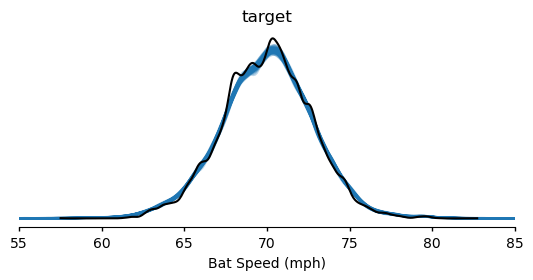

In [16]:
pc = azp.plot_ppc_dist(spp, var_names="target", num_samples=100)
ax = pc.viz["plot"]["target"].item()
ax.set_xlim(55, 85)
ax.set_xlabel("Bat Speed (mph)")

In [17]:
a_posterior_mean = trace_quad.posterior['a'].mean(dim=("chain", "draw")).values.flatten()
b_posterior_mean = trace_quad.posterior['b'].mean(dim=("chain", "draw")).values.flatten()
a_posterior_std = trace_quad.posterior['a'].std(dim=("chain", "draw")).values.flatten()
b_posterior_std = trace_quad.posterior['b'].std(dim=("chain", "draw")).values.flatten()

In [18]:
# compute initial params
m_init, c_init = pm.gp.hsgp_approx.approx_hsgp_hyperparams(
    x_range=[np.min(age_values), np.max(age_values)],
    lengthscale_range=[0.75, 1.25],
    cov_func="expquad",
)
print(f"m: {m_init}, c: {c_init:.2f}")

m: 9, c: 1.20


In [19]:
class QuadraticMean(pm.gp.mean.Mean):
    def __init__(self, a, b):
        self.a = a
        self.b = b

    def __call__(self, X):
        x = X[:, 0]
        return self.a * x**2 + self.b * x

In [20]:
# add position
pdf = df[['bam_id','player_full_id','full','position','position_hybrid']].drop_duplicates(['player_full_id']).reset_index(drop=True)
pdf["position_idx"], position_lookup = define_index(pdf, "position")
position_idx_vals = pdf['position_idx'].values.astype("int32")
position_name_list = list(position_lookup.keys())
pdf.head()

,bam_id,player_full_id,full,position,position_hybrid,position_idx
0,120074,David Ortiz (120074),David Ortiz,DH,DH,0
1,121347,Alex Rodriguez (121347),Alex Rodriguez,SS,UTM,1
2,134181,Adrian Beltré (134181),Adrian Beltré,3B,CINF,2
3,136860,Carlos Beltrán (136860),Carlos Beltrán,CF,UTM,3
4,150029,Jayson Werth (150029),Jayson Werth,RF,COF,4


In [21]:
coords = {
    "observation_id": np.arange(n_obs),
    "player": player_name_list,
    "position": position_name_list
}

with pm.Model(coords=coords) as model_gp_position:
    # data
    player_idx = pm.Data("player_idx", player_idx_vals, dims=("observation_id",))
    age_data = pm.Data("age_data", age_values.reshape(-1, 1))
    swings_sqrt = pm.Data('swings_sqrt', swings_sqrt_values, dims=("observation_id",))
    position_idx = pm.Data('position_idx', position_idx_vals, dims=('player',))
    is_imputed_data = pm.Data('is_imputed_data', is_imputed_data_vals, dims=("observation_id",))
    target_data = pm.Data("target_data", bat_speed_target, dims=("observation_id",))
    
    # global intercept
    mu_pop = pm.Normal("mu_pop", mu=prior_mean, sigma=prior_std)

    # position
    sigma_position = pm.HalfNormal("sigma_position", 1.0)
    position_effect = pm.ZeroSumNormal("position_effect", sigma=sigma_position, dims="position")
    # player
    sigma_player = pm.HalfNormal("sigma_player", 1.0)
    mu_player = pm.Normal("mu_player", mu=mu_pop + position_effect[position_idx], sigma=sigma_player, dims=("player",))
    
    # priors
    a = pm.Normal("a", mu=a_posterior_mean, sigma=a_posterior_std)
    b = pm.Normal("b", mu=b_posterior_mean, sigma=b_posterior_std)
    mean = QuadraticMean(a, b)
    # covariance priors
    eta = pm.HalfNormal("eta", 0.25)
    ls = pm.InverseGamma("ls", alpha=15, beta=14)
    cov_func = eta**2 * pm.gp.cov.ExpQuad(input_dim=1, ls=ls)
    # HSGP
    gp_position = pm.gp.HSGP(m=[m_init], c=c_init, drop_first=True, mean_func=mean, cov_func=cov_func)
    f = gp_position.prior("f", X=age_data)
    
    # expected value
    theta = mu_player[player_idx] + f
    sigma_imputed = pm.HalfNormal("sigma_imputed", sigma=1.0)
    sigma_observed = pm.HalfNormal("sigma_observed", sigma=1.0)
    sigma = pm.math.switch(is_imputed_data, sigma_imputed, sigma_observed)
    target = pm.Normal("target", mu=theta, sigma=sigma/swings_sqrt, observed=target_data, dims=("observation_id",))

In [22]:
trace_gp_position = sample(model_gp_position, draws = 2000, tune = 4000, target_accept = 0.99,  path='gp_expquad_quadratic_position.nc')

NUTS[nutpie]: [mu_pop, sigma_position, position_effect, sigma_player, mu_player, a, b, eta, ls, f_hsgp_coeffs, sigma_imputed, sigma_observed]


Output()

In [243]:
az.summary(trace_gp_position, var_names=['eta','ls','mu_pop','sigma_player','a','b','sigma_imputed','sigma_observed',
                                         'sigma_position','position_effect'], ci_prob=0.95, round_to=2)

,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
eta,0.23,0.08,0.12,0.43,460.32,838.72,1.01,0.00,0.00
ls,0.70,0.11,0.50,0.92,688.84,1084.05,1.01,0.00,0.00
mu_pop,69.80,0.07,69.66,69.95,2015.42,3553.45,1.00,0.00,0.00
sigma_player,2.34,0.04,2.26,2.43,8622.01,6246.40,1.00,0.00,0.00
a[0],-0.13,0.00,-0.14,-0.12,525.01,1126.42,1.00,0.00,0.00
b[0],0.03,0.01,0.02,0.05,1397.68,2454.56,1.00,0.00,0.00
sigma_imputed,4.86,0.03,4.81,4.92,6927.87,5693.89,1.00,0.00,0.00
sigma_observed,14.24,0.11,14.02,14.46,7357.10,6327.53,1.00,0.00,0.00
sigma_position,1.17,0.28,0.74,1.82,8280.11,5738.65,1.00,0.00,0.00
position_effect[DH],2.09,0.28,1.53,2.63,8242.66,6376.22,1.00,0.00,0.00


In [ ]:
player_effects = az.summary(trace_gp_position, var_names=['mu_player'], ci_prob=0.95, round_to=2)
player_effects = player_effects.reset_index(drop=False)
player_effects['player_full_id'] = player_effects['index'].str.extract(r'\[(.*?)\]')
player_effects.tail(10)

,index,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd,player_full_id
1699,mu_player[Spencer Jones (682987)],76.18,0.71,74.78,77.58,10180.32,6237.73,1.0,0.01,0.0,Spencer Jones (682987)
1700,mu_player[Jac Caglianone (695506)],76.55,0.39,75.78,77.33,10711.05,6129.77,1.0,0.00,0.0,Jac Caglianone (695506)
1701,mu_player[Nelson Cruz (443558)],76.77,0.06,76.64,76.89,4858.53,5476.40,1.0,0.00,0.0,Nelson Cruz (443558)
1702,mu_player[Jhonkensy Noel (678877)],76.82,0.52,75.80,77.84,11105.27,6208.57,1.0,0.00,0.0,Jhonkensy Noel (678877)
1703,mu_player[Vladimir Guerrero Jr. (665489)],76.85,0.07,76.70,76.99,2365.37,4497.88,1.0,0.00,0.0,Vladimir Guerrero Jr. (665489)
1704,mu_player[Nick Kurtz (701762)],76.95,0.37,76.23,77.68,10434.04,6394.86,1.0,0.00,0.0,Nick Kurtz (701762)
1705,mu_player[Aaron Judge (592450)],77.47,0.06,77.34,77.60,1596.17,3411.67,1.0,0.00,0.0,Aaron Judge (592450)
1706,mu_player[Oneil Cruz (665833)],77.57,0.16,77.26,77.88,6656.44,5766.08,1.0,0.00,0.0,Oneil Cruz (665833)
1707,mu_player[Junior Caminero (691406)],78.24,0.29,77.66,78.79,10269.78,6237.17,1.0,0.00,0.0,Junior Caminero (691406)
1708,mu_player[Giancarlo Stanton (519317)],79.54,0.07,79.42,79.67,1726.44,3144.90,1.0,0.00,0.0,Giancarlo Stanton (519317)


In [53]:
player_effects.head(10)

,index,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd,player_full_id
0,mu_player[Michael Papierski (657709)],62.07,0.35,61.38,62.77,10261.03,6591.14,1.0,0.0,0.0,Michael Papierski (657709)
1,mu_player[Billy Hamilton (571740)],62.42,0.08,62.26,62.57,3101.00,4319.93,1.0,0.0,0.0,Billy Hamilton (571740)
2,mu_player[Juan Graterol (492802)],62.96,0.31,62.37,63.56,10532.09,6445.30,1.0,0.0,0.0,Juan Graterol (492802)
3,mu_player[Jake Elmore (518653)],62.97,0.31,62.37,63.57,10913.07,6250.72,1.0,0.0,0.0,Jake Elmore (518653)
4,mu_player[Dee Strange-Gordon (543829)],63.11,0.08,62.96,63.27,2546.60,4125.51,1.0,0.0,0.0,Dee Strange-Gordon (543829)
5,mu_player[Ronald Torreyes (591720)],63.22,0.12,62.99,63.45,6161.49,6227.47,1.0,0.0,0.0,Ronald Torreyes (591720)
6,mu_player[Billy Burns (542993)],63.33,0.20,62.93,63.72,9354.33,5760.84,1.0,0.0,0.0,Billy Burns (542993)
7,mu_player[Shane Robinson (453203)],63.46,0.27,62.93,64.00,9925.09,5520.80,1.0,0.0,0.0,Shane Robinson (453203)
8,mu_player[Terrance Gore (605253)],63.47,0.41,62.65,64.27,9422.88,6351.87,1.0,0.0,0.0,Terrance Gore (605253)
9,mu_player[Ben Revere (519184)],63.60,0.15,63.30,63.90,6997.13,6273.92,1.0,0.0,0.0,Ben Revere (519184)


In [56]:
last_play = df.groupby('player_full_id')['time_index'].max().reset_index()
last_play = last_play.merge(df[['player_full_id','time_index','month_name','year']], how='left', on=['player_full_id','time_index'])
last_play = last_play.merge(player_effects, on=['player_full_id'])
last_play = last_play.sort_values(['mean'])
last_play.head()

,player_full_id,time_index,month_name,year,index,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
1175,Michael Papierski (657709),40,Aug,2022,mu_player[Michael Papierski (657709)],62.07,0.35,61.38,62.77,10261.03,6591.14,1.0,0.0,0.0
146,Billy Hamilton (571740),41,Sep/Oct,2022,mu_player[Billy Hamilton (571740)],62.42,0.08,62.26,62.57,3101.00,4319.93,1.0,0.0,0.0
943,Juan Graterol (492802),23,Sep/Oct,2019,mu_player[Juan Graterol (492802)],62.96,0.31,62.37,63.56,10532.09,6445.30,1.0,0.0,0.0
745,Jake Elmore (518653),23,Sep/Oct,2019,mu_player[Jake Elmore (518653)],62.97,0.31,62.37,63.57,10913.07,6250.72,1.0,0.0,0.0
460,Dee Strange-Gordon (543829),38,Jun,2022,mu_player[Dee Strange-Gordon (543829)],63.11,0.08,62.96,63.27,2546.60,4125.51,1.0,0.0,0.0


In [60]:
bottom = last_play.loc[(last_play['year']==2026)].head()
bottom

,player_full_id,time_index,month_name,year,index,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
733,Jacob Wilson (805779),64,Aug,2026,mu_player[Jacob Wilson (805779)],63.81,0.36,63.10,64.52,9643.78,6503.19,1.0,0.00,0.0
298,Chandler Simpson (802415),64,Aug,2026,mu_player[Chandler Simpson (802415)],64.15,0.39,63.38,64.90,10349.24,6635.74,1.0,0.00,0.0
609,Garrett Stubbs (596117),64,Aug,2026,mu_player[Garrett Stubbs (596117)],64.22,0.22,63.78,64.65,9292.15,5901.04,1.0,0.00,0.0
398,César Salazar (663967),61,May,2026,mu_player[César Salazar (663967)],64.34,0.59,63.20,65.51,10489.90,6097.45,1.0,0.01,0.0
1595,Tyler Heineman (623168),64,Aug,2026,mu_player[Tyler Heineman (623168)],64.54,0.21,64.14,64.95,8645.17,6115.46,1.0,0.00,0.0


In [61]:
top = last_play.loc[(last_play['year']==2026)].tail()
top

,player_full_id,time_index,month_name,year,index,mean,sd,eti95_lb,eti95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
1244,Nick Kurtz (701762),63,Jul,2026,mu_player[Nick Kurtz (701762)],76.95,0.37,76.23,77.68,10434.04,6394.86,1.0,0.0,0.0
9,Aaron Judge (592450),61,May,2026,mu_player[Aaron Judge (592450)],77.47,0.06,77.34,77.60,1596.17,3411.67,1.0,0.0,0.0
1280,Oneil Cruz (665833),64,Aug,2026,mu_player[Oneil Cruz (665833)],77.57,0.16,77.26,77.88,6656.44,5766.08,1.0,0.0,0.0
953,Junior Caminero (691406),64,Aug,2026,mu_player[Junior Caminero (691406)],78.24,0.29,77.66,78.79,10269.78,6237.17,1.0,0.0,0.0
620,Giancarlo Stanton (519317),60,Mar/Apr,2026,mu_player[Giancarlo Stanton (519317)],79.54,0.07,79.42,79.67,1726.44,3144.90,1.0,0.0,0.0


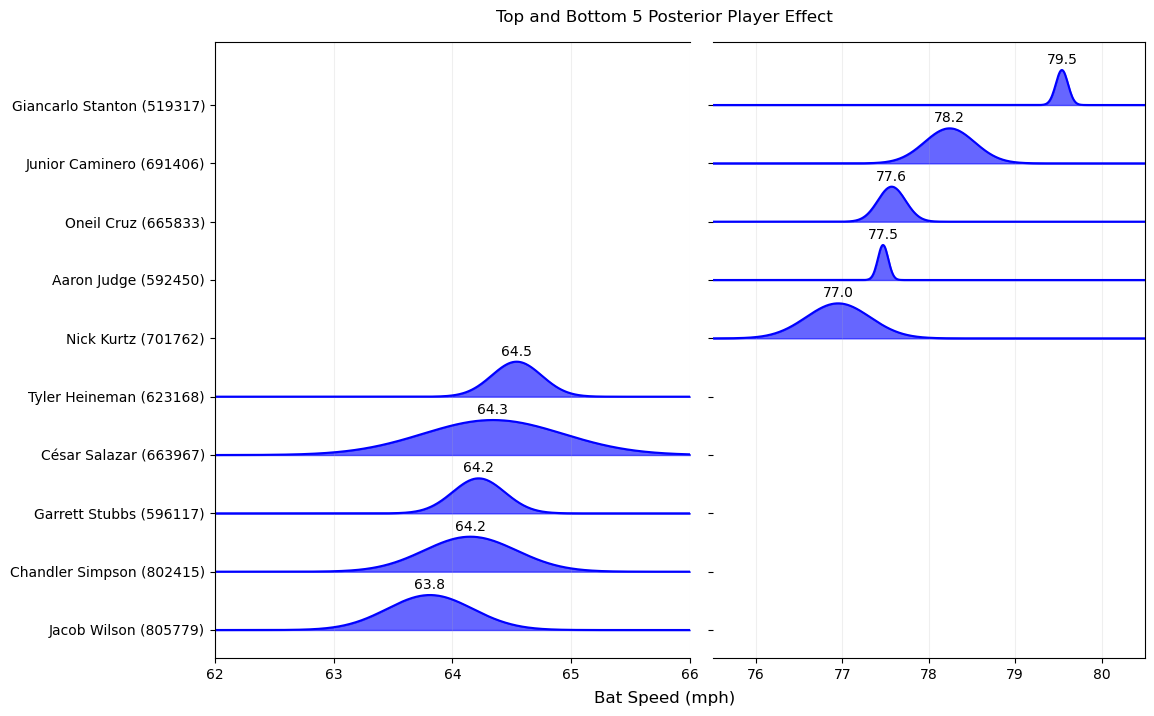

In [107]:
top_bottom = pd.concat([top, bottom]).sort_values("mean").reset_index(drop=True)
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(12, 8), sharey=True,
    gridspec_kw={"width_ratios": [1.1, 1.0], "wspace": 0.05}
)
axes = [ax1, ax2]
ranges = [(62, 66), (75.5, 80.5)]
for ax, (xmin, xmax), group in zip(axes, ranges, [bottom, top]):
    x = np.linspace(xmin, xmax, 500)
    for i, row in top_bottom.iterrows():
        if row["player_full_id"] not in set(group["player_full_id"]):
            continue
        pdf = np.exp(-0.5 * ((x - row["mean"]) / row["sd"]) ** 2)
        pdf = pdf / pdf.max() * 0.6
        ax.fill_between(x, i, i + pdf, alpha=0.6, color="blue")
        ax.plot(x, i + pdf, color="blue")
        if xmin <= row["mean"] <= xmax:
            ax.text(row["mean"], i + 0.65, f"{row['mean']:.1f}", ha="center", va="bottom")
    ax.set_xlim(xmin, xmax)
    ax.grid(axis="x", alpha=0.2)
ax1.set_xticks(range(62, 67))
ax1.set_yticks(range(len(top_bottom)))
ax1.set_yticklabels(top_bottom["player_full_id"])
ax1.set_ylabel("")
ax1.spines["right"].set_visible(False)
ax2.spines["left"].set_visible(False)
ax2.tick_params(labelleft=False)
fig.supxlabel("Bat Speed (mph)", y=0.05)
fig.suptitle("Top and Bottom 5 Posterior Player Effect", y=0.92)
plt.show()

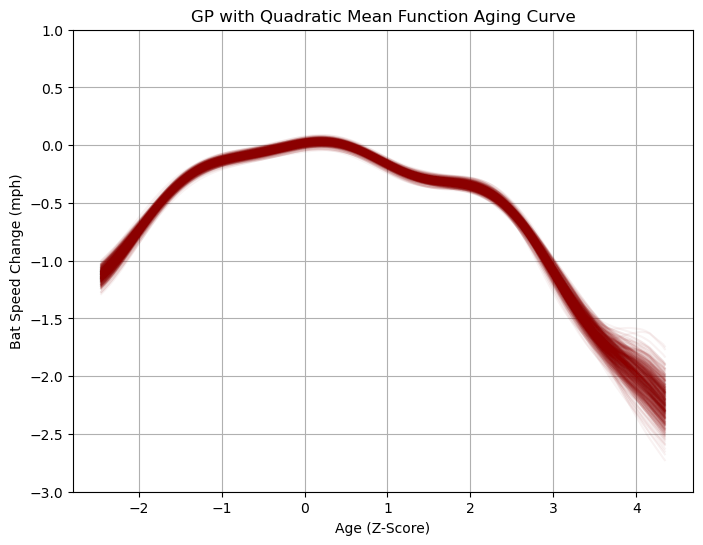

In [33]:
gp_aging_curve = plot_aging_curve(trace_gp_position, age_values, model_name="GP with Quadratic Mean Function")

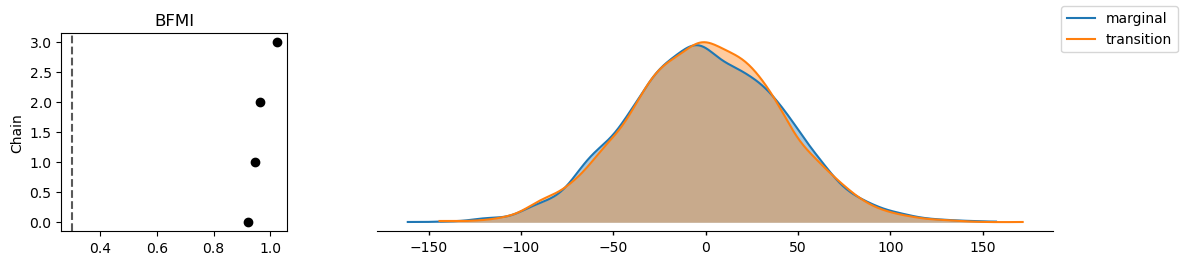

In [34]:
az.plot_energy(trace_gp_position)

In [35]:
spp = sample_posterior_pred(model_gp_position, trace_gp_position)

Sampling: [target]


Output()

Text(0.5, 1.0, 'Posterior Predictive: Bat Speed')

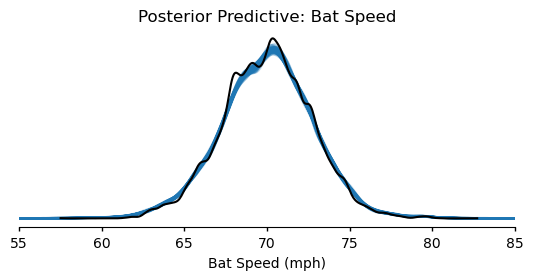

In [240]:
pc = azp.plot_ppc_dist(spp, var_names="target", num_samples=100)
ax = pc.viz["plot"]["target"].item()
ax.set_xlim(55, 85)
ax.set_xlabel("Bat Speed (mph)")
ax.set_title("Posterior Predictive: Bat Speed")

In [ ]:
posit_means = trace_gp_position.posterior['position_effect'].mean(('chain','draw'))
sorted_coord = trace_gp_position.posterior['position'].sortby(posit_means)
posit_mean_sorted = trace_gp_position.sel(position=sorted_coord)

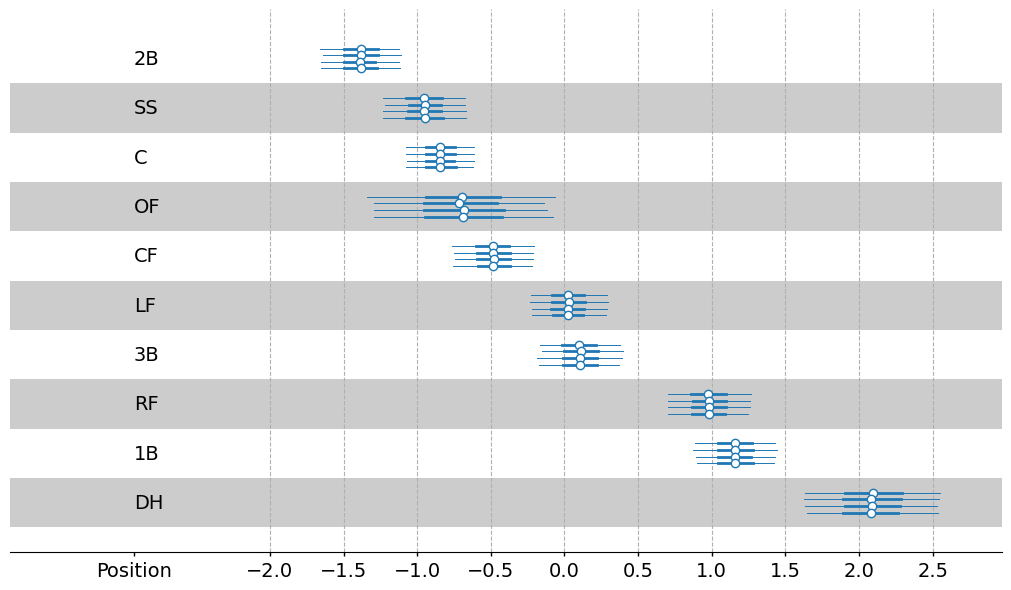

In [ ]:
def rename_position(ds):
    if "position" in ds.dims:
        return ds.rename({"position": "Position"})
    return ds

posit_mean_sorted = posit_mean_sorted.map_over_datasets(rename_position)
pc = azp.plot_forest(
    posit_mean_sorted,
    var_names=['position_effect'],
    shade_label='Position',
    labels=['Position'],
    visuals={'remove_axis': True}
)
for text in plt.gcf().findobj(mtext.Text):
    text.set_fontsize(14)
ax = plt.gca()
ax.tick_params(axis='both', labelsize=14)
ax.grid(True, axis='x', linestyle='--')
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.5))
plt.show()

In [108]:
df.columns

Index(['bam_id', 'year', 'month_name', 'time_index', 'player_full_id', 'full',
       'first', 'last', 'bats', 'birth_date', 'position', 'position_group',
       'position_hybrid', 'age', 'bips', 'ev90', 'latent_ev90_mean',
       'latent_ev90_std', 'swing_total', 'bat_speed', 'imputed_bat_speed',
       'model_bat_speed', 'is_imputed', 'is_complete', 'age_z', 'player_idx'],
      dtype='str')

In [ ]:
def precompute_universal_gp(
    name:str,
    trace=trace_gp_position,
    model=model_gp_position,
    mean_age=age_mean, 
    std_age=age_std
):
    universal_raw_age = np.linspace(18, 45, 300)
    universal_std_age = ((universal_raw_age-mean_age)/std_age).reshape(-1, 1)
    with model:
        _ = gp_position.conditional(name, Xnew=universal_std_age)
        trace_pred = pm.sample_posterior_predictive(
            trace,
            var_names=[name],
            predictions=True
            )
    f_global_samples = az.extract(trace_pred, group="predictions", var_names=name).values
    return universal_raw_age, f_global_samples

In [125]:
name = 'f_pred_age_'
universal_raw_age, f_global_samples = precompute_universal_gp(name=name)

Sampling: []


Output()

In [ ]:
def get_player_projection(
    player_full_id,
    df,
    projection_years,
    universal_raw_age,
    f_global_samples,
    trace=trace_gp_position,
    start_date="2026-09-01",
    plot_start_date="2025-01-01"
):
    player_df = df[df["player_full_id"] == player_full_id].copy()
    if player_df.empty:
        raise ValueError(f"Player {player_full_id} not found in DataFrame.")

    birth_date = pd.to_datetime(player_df["birth_date"].iloc[0])
    start_plot_dt = pd.to_datetime(plot_start_date)
    start_dt = pd.to_datetime(start_date)
    end_dt = start_dt + pd.DateOffset(years=projection_years, months=1)

    min_raw_age = (start_plot_dt - birth_date).days / 365.25
    proj_start_age = (start_dt - birth_date).days / 365.25
    max_raw_age = (end_dt - birth_date).days / 365.25

    mask = (universal_raw_age >= min_raw_age) & (universal_raw_age <= max_raw_age)
    player_age_grid = universal_raw_age[mask]
    f_samples = f_global_samples[mask, :]

    player_coords = list(trace.posterior.coords["player"].values)
    player_key = player_df["player_idx"].iloc[0]
    player_idx_val = player_coords.index(player_key)

    mu_player_samples = az.extract(trace.posterior)["mu_player"].values[player_idx_val, :]
    theta_samples = mu_player_samples[None, :] + f_samples

    return player_age_grid, theta_samples, player_df, proj_start_age

In [ ]:
def plot_player_projection(
    player_full_id,
    df,
    projection_years,
    universal_raw_age,
    f_global_samples,
    trace=trace_gp_position,
    start_date="2026-09-01",
    plot_start_date="2025-01-01",
    ax=None
):
    age_grid, theta_samples, player_df, proj_start_age = get_player_projection(
        player_full_id, df, projection_years, universal_raw_age, f_global_samples, trace, start_date, plot_start_date
    )

    mean_trajectory = theta_samples.mean(axis=1)
    hdi_50 = np.percentile(theta_samples, [25.0, 75.0], axis=1)
    hdi_95 = np.percentile(theta_samples, [2.5, 97.5], axis=1)

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(10, 6))

    ax.fill_between(age_grid, hdi_95[0], hdi_95[1], color="blue", alpha=0.15, label="95% CI")
    ax.fill_between(age_grid, hdi_50[0], hdi_50[1], color="blue", alpha=0.30, label="50% CI")
    ax.plot(age_grid, mean_trajectory, color="navy", lw=2, label="Posterior Mean")

    obs_df = player_df[player_df["age"] >= age_grid[0]]
    ax.scatter(obs_df["age"], obs_df["model_bat_speed"], color="black", label="Observed")
    ax.axvline(x=proj_start_age, color="red", linestyle="--", alpha=0.75)

    title = f"{projection_years}-Year Bat Speed Projection: {player_full_id}" if standalone else player_full_id
    ax.set_title(title)
    ax.set_xlabel("Age")
    ax.set_ylabel("Bat Speed (mph)")
    ax.grid(alpha=0.2)
    ax.legend(loc="upper right")

    if standalone:
        ax.set_ylim(round(min(player_df["model_bat_speed"]) - 2, 0), round(max(player_df["model_bat_speed"]) + 2, 0))
        plt.tight_layout()
        plt.show()

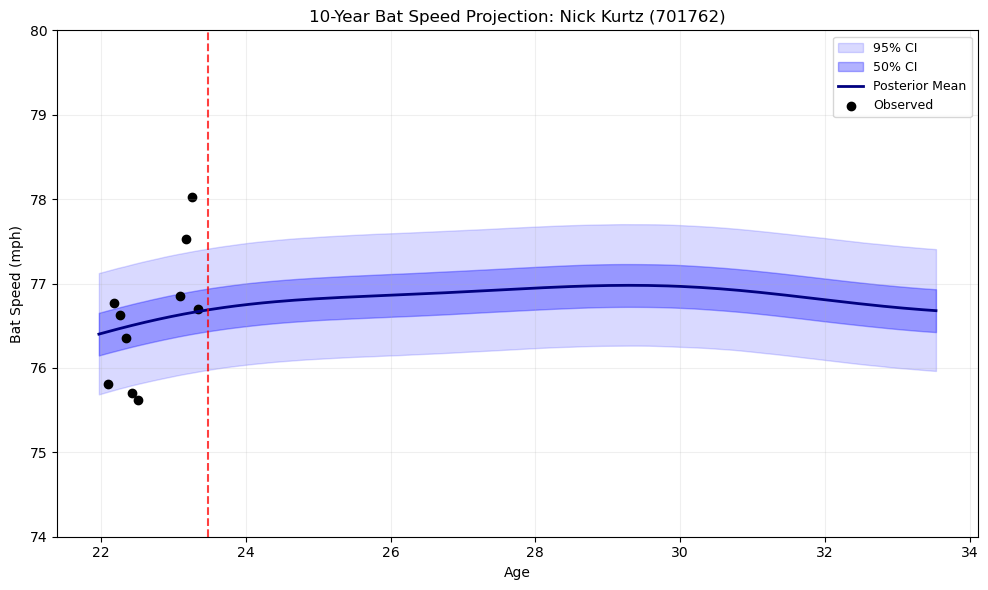

In [219]:
player_full_id='Nick Kurtz (701762)'
projection_years=10
plot_start_date = '2025-03-01'
plot_player_projection(player_full_id, df, projection_years, universal_raw_age, f_global_samples, plot_start_date=plot_start_date)

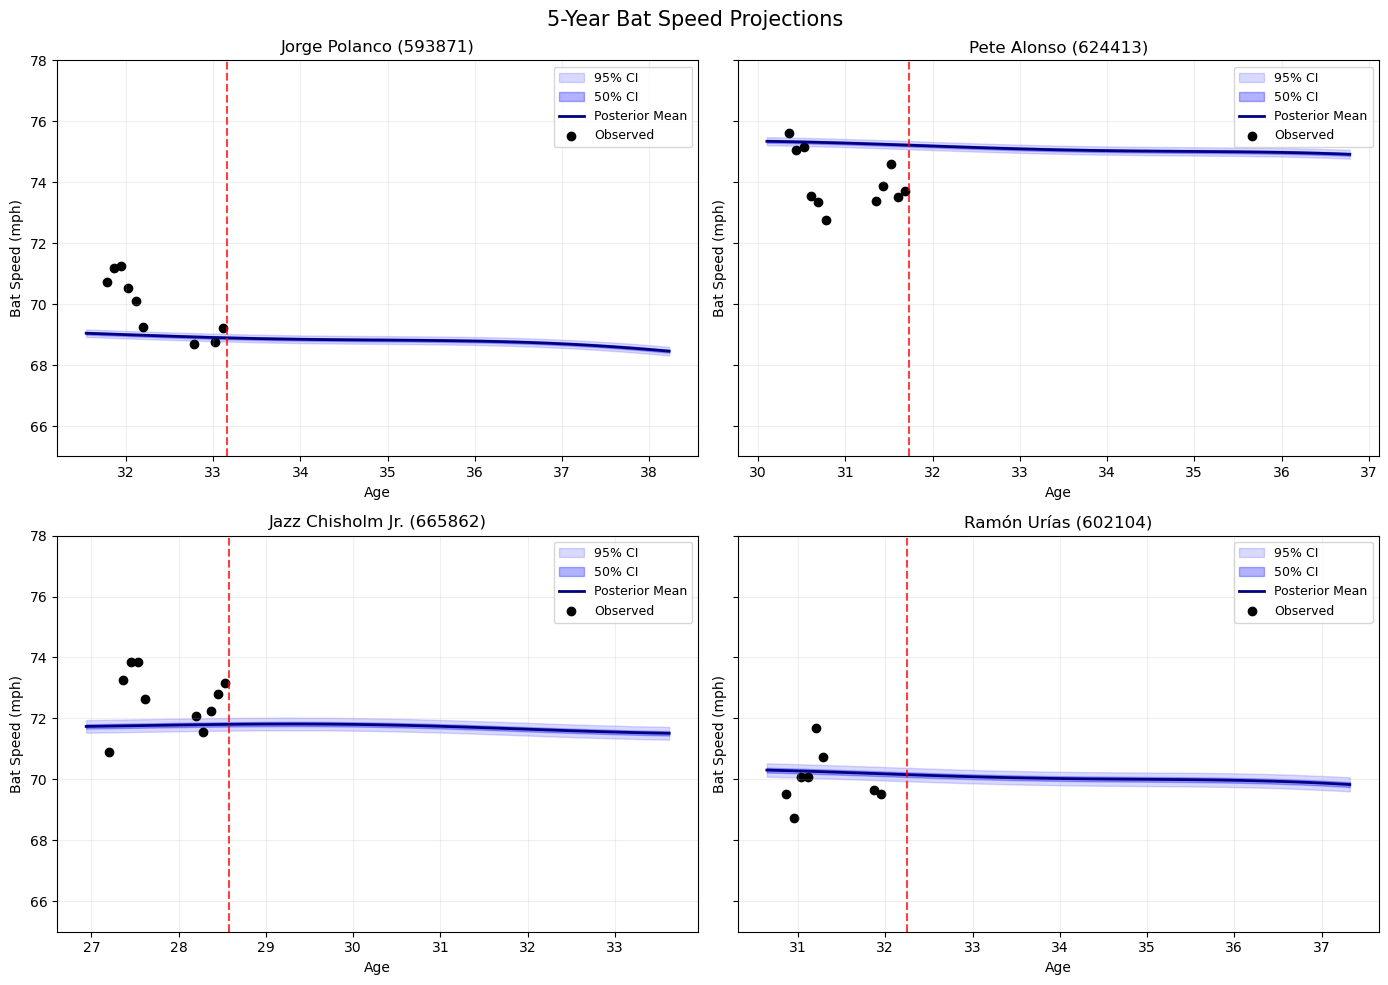

In [ ]:
def plot_4player_2x2_projections(
    player_ids,
    df,
    projection_years,
    universal_raw_age,
    f_global_samples,
    trace=trace_gp_position,
    start_date="2026-09-01",
    plot_start_date="2025-01-01"
):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
    for player_id, ax in zip(player_ids, axes.flat):
        plot_player_projection(
            player_id,
            df,
            projection_years,
            universal_raw_age,
            f_global_samples,
            trace=trace,
            start_date=start_date,
            plot_start_date=plot_start_date,
            ax=ax
        )

    sub_df = df[df["player_full_id"].isin(player_ids)]
    global_min = round(sub_df["model_bat_speed"].min() - 2, 0)
    global_max = round(sub_df["model_bat_speed"].max() + 2, 0)

    for ax in axes.flat:
        ax.set_ylim(global_min, global_max)

    fig.suptitle(f"{projection_years}-Year Bat Speed Projections")
    plt.tight_layout()
    plt.show()

player_list = [
    "Jorge Polanco (593871)",
    "Pete Alonso (624413)",
    "Jazz Chisholm Jr. (665862)",
    "Ramón Urías (602104)"
]

plot_4player_2x2_projections(
    player_ids=player_list,
    df=df,
    projection_years=5,
    universal_raw_age=universal_raw_age,
    f_global_samples=f_global_samples,
    plot_start_date="2025-01-01"
)

In [221]:
df.loc[df['bam_id']==650333].groupby('is_imputed')['model_bat_speed'].mean()

is_imputed
0    62.444162
1    65.539058
Name: model_bat_speed, dtype: float64

In [234]:
player_df = df.loc[df['bam_id']==650333]

player_coords = list(trace_gp_position.posterior.coords["player"].values)
player_key = player_df["player_idx"].min()
az.extract(trace_gp_position.posterior)["mu_player"].values[player_key, :].mean()

np.float64(65.40030859137772)

In [245]:
player_effects.to_csv('mu_player.csv')